## **Inference Notebook for Clustering and Classification using Credit Card Spending Data**

#### By: John Adrian T. Ada

---
### **Abstract** 

---

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
from sklearn.cluster import HDBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (silhouette_score, 
                            silhouette_samples, 
                            calinski_harabasz_score, 
                            davies_bouldin_score)

import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

### **Methods**

The methods used for this consists of common pre-processing and Exploratory Data Analysis techniques such as null-value handling and exploratory visualization. Then, K-means clustering is used as unsupervised machine learning to determine the number of labels. Cluster analysis determines the characteristics of each label before multiple model training to classify each observation. 

---
### **0. Dataset Information**

The dataset used for this project is a credit card dataset retried from Kaggle. It was part of an assignment to be submitted on sampling to study various sampling techniques and evaluate the performance of those techniques. The dataset has no labels, no pre-determined target variable. The "Class" column may serve as the target variable but since it is not defined. 

Dataset link: https://www.kaggle.com/datasets/akshita0560/credit-card

In this project, it was used for consumer segmentation using unsupervised Machine Learning such as Clustering to determine different types of consumers before using Supervised Machine Learning to predict the labels determined from clustering. 

---
### **1. Data Loading and Pre-processing**


In [4]:
df = pd.read_csv(r'../data/Creditcard_data.csv')

df.drop(['Class', 'Time'], axis=1, inplace=True)
print(df.columns)
df.head()

Index(['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11',
       'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21',
       'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount'],
      dtype='str')


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99


In [12]:
df.info()

print('=' * 50)
if df.isna().sum().sum() == 0:
    print("No missing values")

<class 'pandas.DataFrame'>
RangeIndex: 772 entries, 0 to 771
Data columns (total 29 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   V1      772 non-null    float64
 1   V2      772 non-null    float64
 2   V3      772 non-null    float64
 3   V4      772 non-null    float64
 4   V5      772 non-null    float64
 5   V6      772 non-null    float64
 6   V7      772 non-null    float64
 7   V8      772 non-null    float64
 8   V9      772 non-null    float64
 9   V10     772 non-null    float64
 10  V11     772 non-null    float64
 11  V12     772 non-null    float64
 12  V13     772 non-null    float64
 13  V14     772 non-null    float64
 14  V15     772 non-null    float64
 15  V16     772 non-null    float64
 16  V17     772 non-null    float64
 17  V18     772 non-null    float64
 18  V19     772 non-null    float64
 19  V20     772 non-null    float64
 20  V21     772 non-null    float64
 21  V22     772 non-null    float64
 22  V23     772 n

In [9]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
V1,772.0,-0.176963,1.294724,-6.093248,-0.896416,-0.382618,1.110739,1.586093
V2,772.0,0.217169,1.173401,-12.114213,-0.174684,0.285843,0.885745,5.267376
V3,772.0,0.875172,1.031878,-5.694973,0.308677,0.905435,1.532969,3.772857
V4,772.0,0.285628,1.258758,-4.657545,-0.460058,0.395919,1.117559,4.075817
V5,772.0,-0.005029,1.098143,-6.631951,-0.534567,-0.116612,0.452818,7.672544
V6,772.0,0.159081,1.225682,-3.498447,-0.630717,-0.109581,0.482972,5.122103
V7,772.0,0.123329,0.852075,-4.925568,-0.296289,0.116329,0.575390,4.808426
V8,772.0,-0.057547,0.830144,-7.494658,-0.167880,0.034755,0.252395,2.134599
V9,772.0,-0.030384,0.878183,-2.770089,-0.517068,-0.082270,0.412261,5.459274
V10,772.0,0.033306,0.969363,-2.772272,-0.401168,-0.094473,0.264487,8.821756


In [16]:
len(df.columns)

29

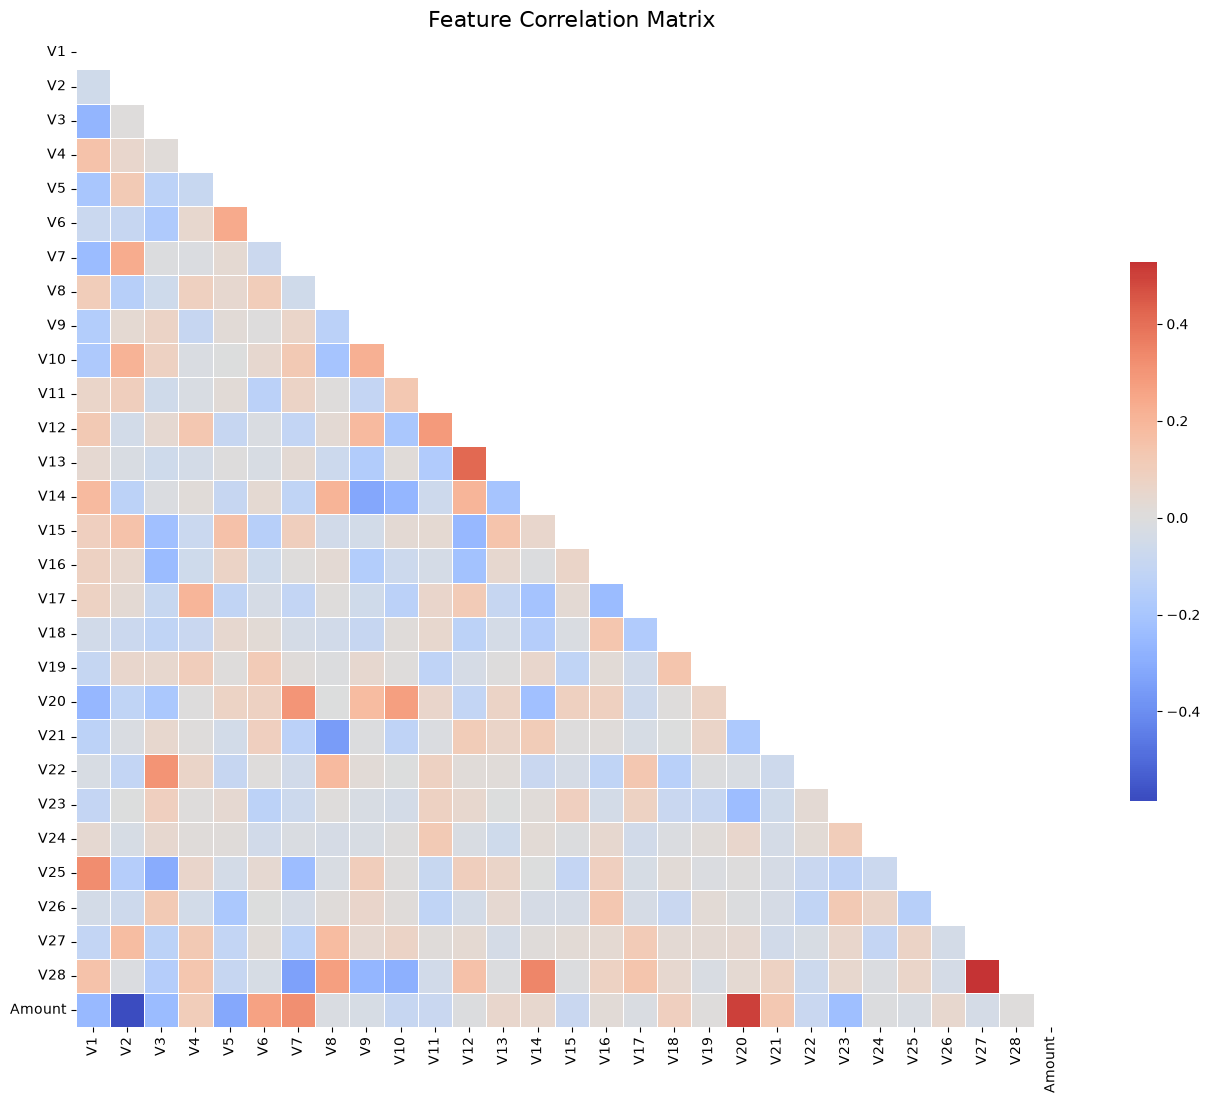

Maximum correlation less than 1: 0.5282406745176873


In [ ]:
#heatmap correlation
corr_matrix = df.corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(16, 14))

sns.heatmap(
    corr_matrix, 
    mask=mask,               
    cmap='coolwarm',         
    center=0,                
    square=True,             
    linewidths=0.5,          
    cbar_kws={"shrink": 0.5} 
)

plt.title('Feature Correlation Matrix', fontsize=16)
plt.show()

print('=' * 50)
#print max correlation that is less than 1 
print("Maximum correlation less than 1:", corr_matrix[corr_matrix < 1].max().max())

In [23]:
corr_matrix

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
V1,1.000000,-0.056706,-0.267204,0.153822,-0.197934,-0.075957,-0.242849,0.104856,-0.159691,-0.177685,...,-0.261267,-0.131440,-0.027551,-0.106046,0.038942,0.327760,-0.043160,-0.108741,0.153592,-0.250625
V2,-0.056706,1.000000,0.010161,0.051302,0.120680,-0.097551,0.234791,-0.147553,0.033720,0.215258,...,-0.116070,-0.016272,-0.107399,-0.005340,-0.030438,-0.154725,-0.063960,0.175478,-0.013166,-0.584368
V3,-0.267204,0.010161,1.000000,0.015942,-0.132168,-0.171821,-0.009910,-0.059532,0.070927,0.080864,...,-0.188139,0.049164,0.306866,0.092805,0.041955,-0.303991,0.122476,-0.130051,-0.158116,-0.243193
V4,0.153822,0.051302,0.015942,1.000000,-0.087504,0.048616,-0.014033,0.088808,-0.092848,-0.017568,...,0.000575,0.004470,0.064825,0.005048,0.011168,0.057722,-0.047818,0.124666,0.139668,0.107817
V5,-0.197934,0.120680,-0.132168,-0.087504,1.000000,0.237238,0.036939,0.041840,0.022105,-0.005058,...,0.072480,-0.045511,-0.094363,0.040757,0.013155,-0.044092,-0.184745,-0.107097,-0.095837,-0.316297
V6,-0.075957,-0.097551,-0.171821,0.048616,0.237238,1.000000,-0.071915,0.109445,0.001797,0.042066,...,0.081156,0.090164,0.004394,-0.131565,-0.051277,0.040252,-0.005329,0.016108,-0.031591,0.264066
V7,-0.242849,0.234791,-0.009910,-0.014033,0.036939,-0.071915,1.000000,-0.055663,0.059454,0.127311,...,0.300704,-0.134241,-0.049840,-0.068024,-0.015250,-0.238334,-0.035350,-0.129259,-0.340514,0.323121
V8,0.104856,-0.147553,-0.059532,0.088808,0.041840,0.109445,-0.055663,1.000000,-0.134316,-0.209927,...,-0.005026,-0.355149,0.181168,0.005021,-0.032937,-0.023092,0.013989,0.179232,0.273840,-0.018887
V9,-0.159691,0.033720,0.070927,-0.092848,0.022105,0.001797,0.059454,-0.134316,1.000000,0.222936,...,0.178513,-0.009783,0.020452,-0.027559,-0.026912,0.102079,0.056156,0.038298,-0.264003,-0.028870
V10,-0.177685,0.215258,0.080864,-0.017568,-0.005058,0.042066,0.127311,-0.209927,0.222936,1.000000,...,0.272223,-0.119745,-0.004525,-0.045153,-0.000097,0.002782,0.012754,0.068080,-0.290941,-0.093998


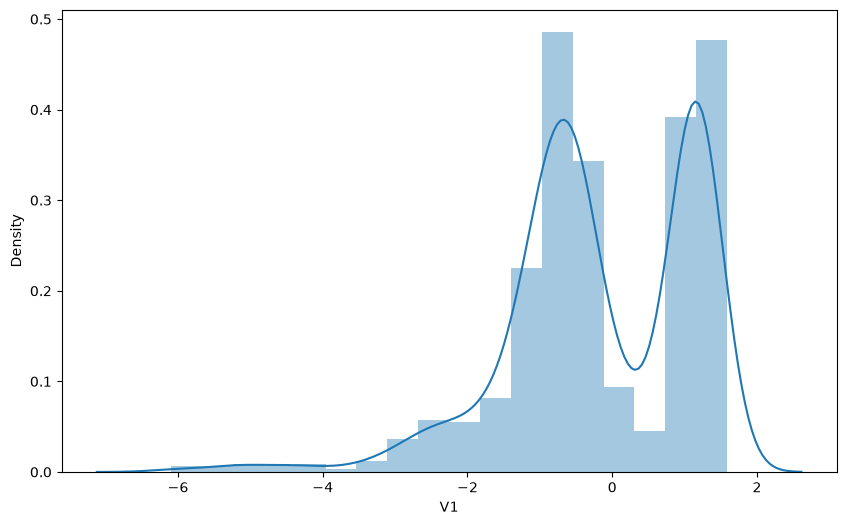

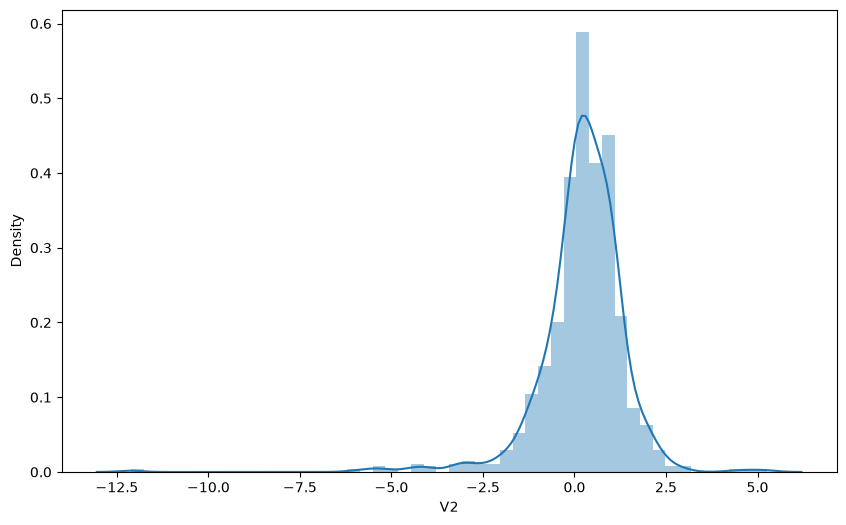

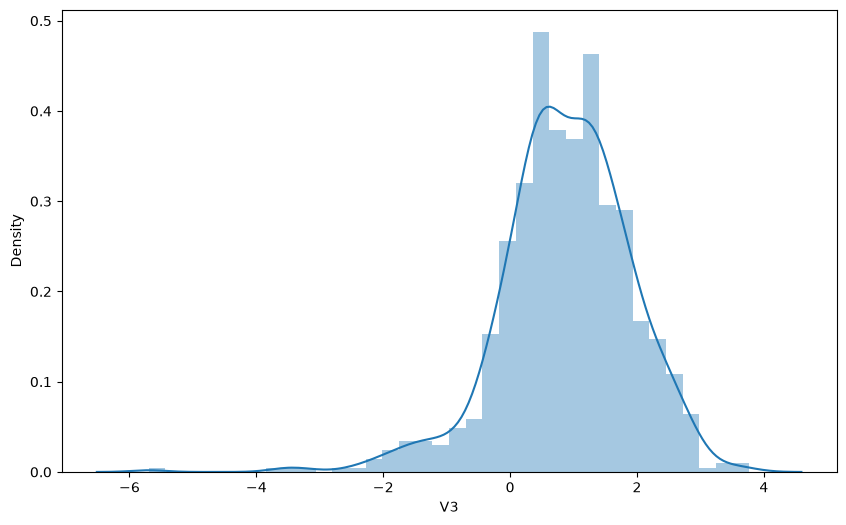

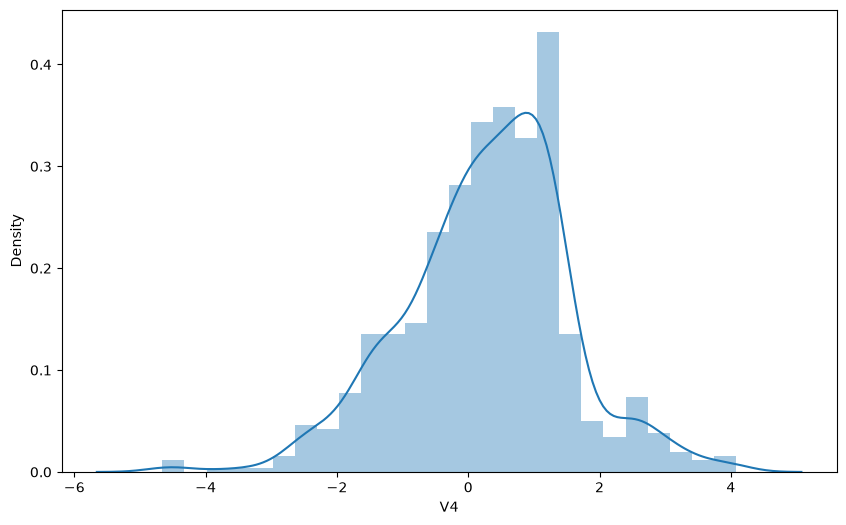

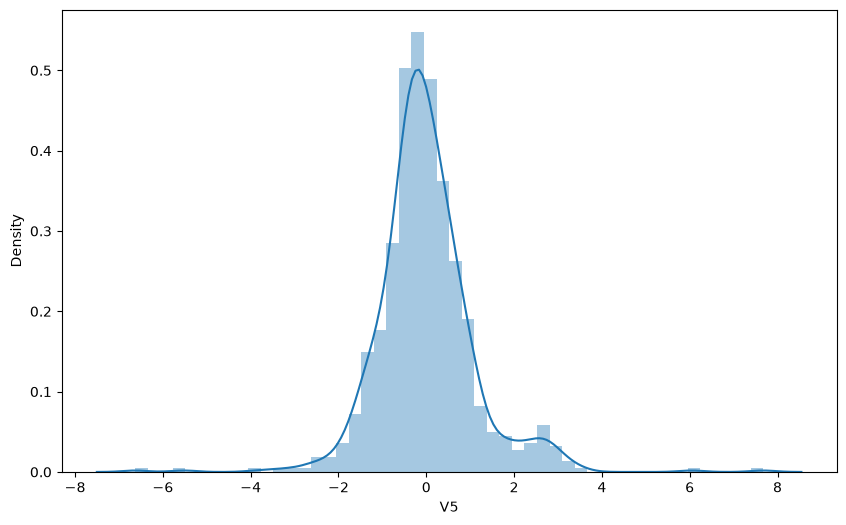

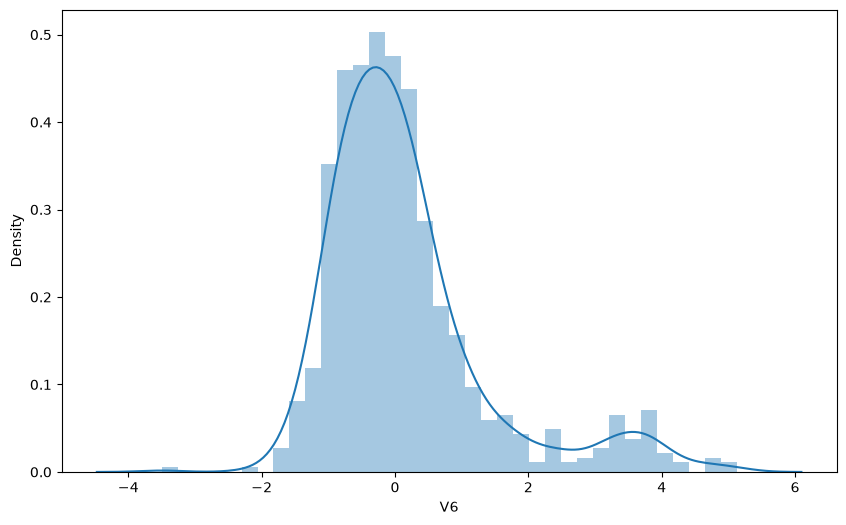

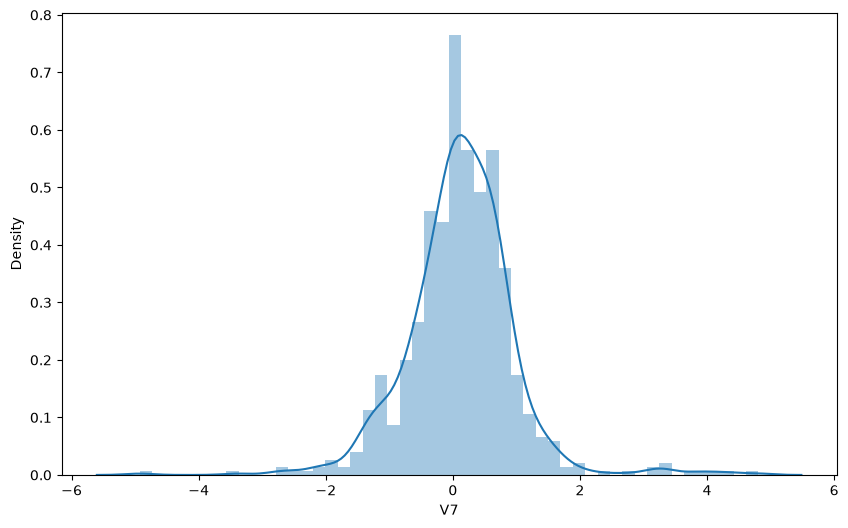

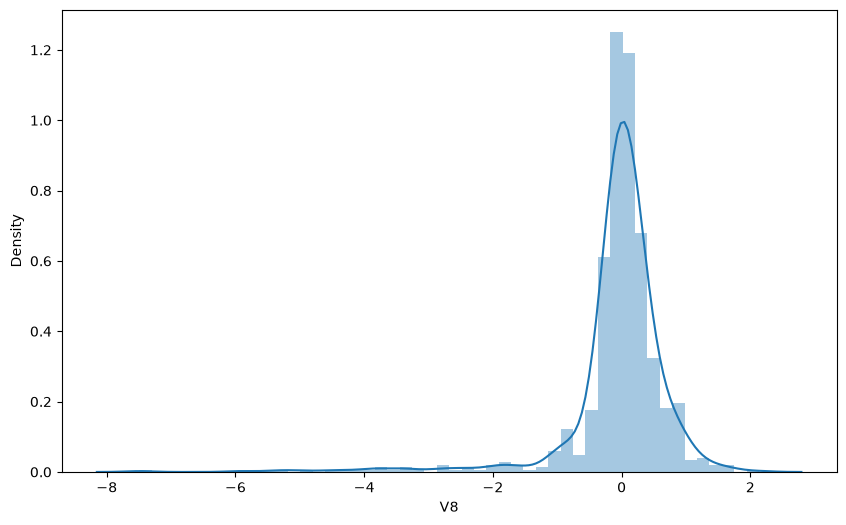

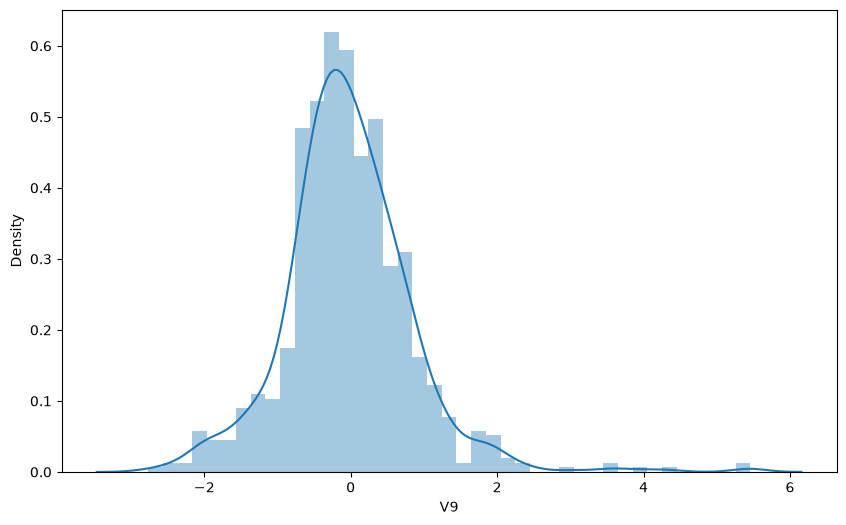

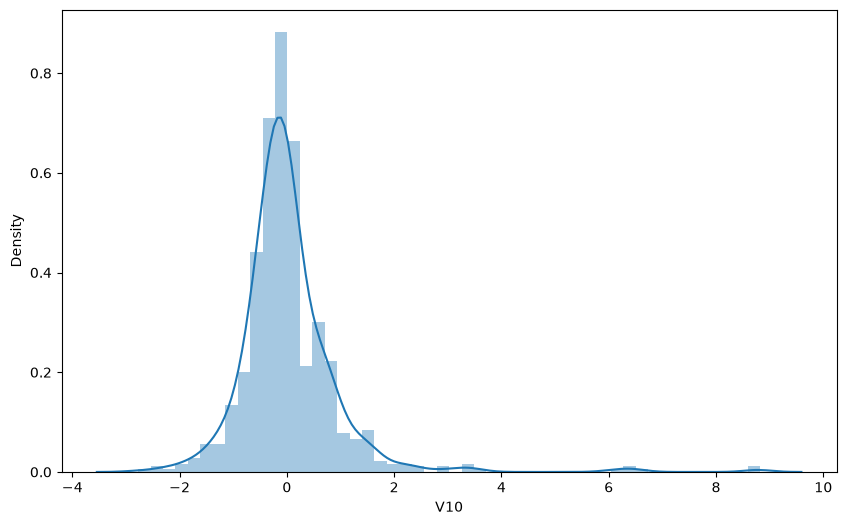

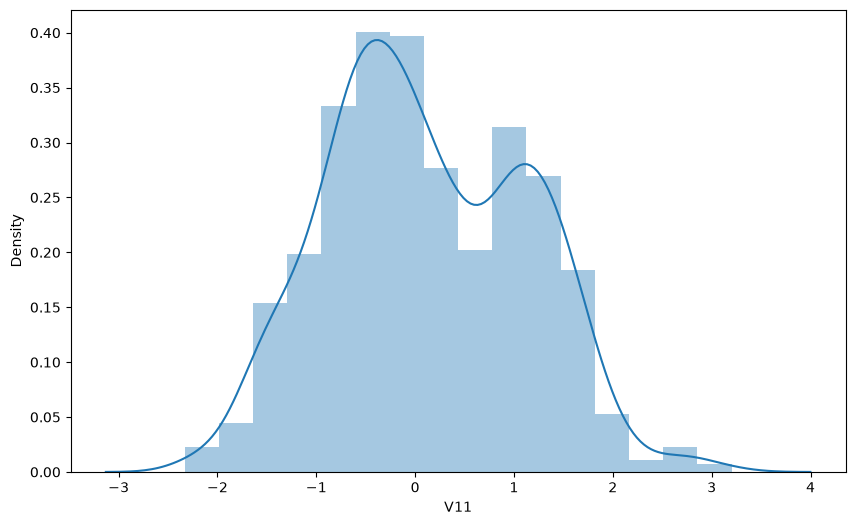

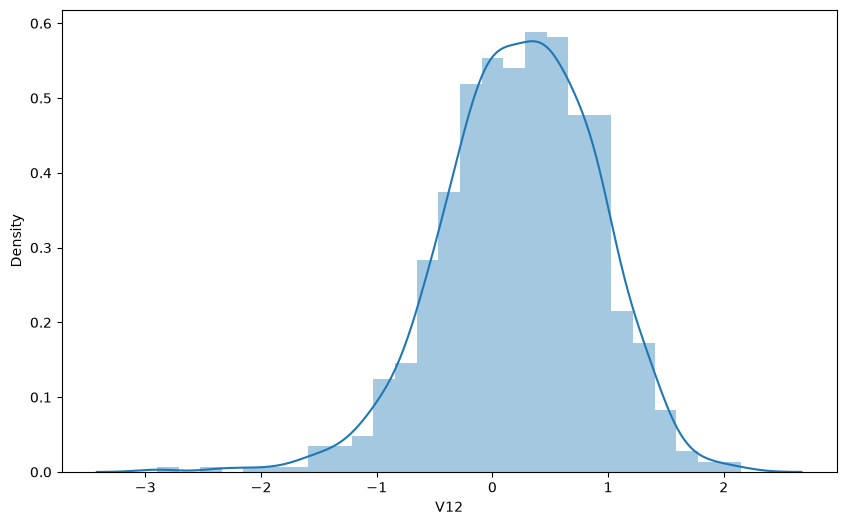

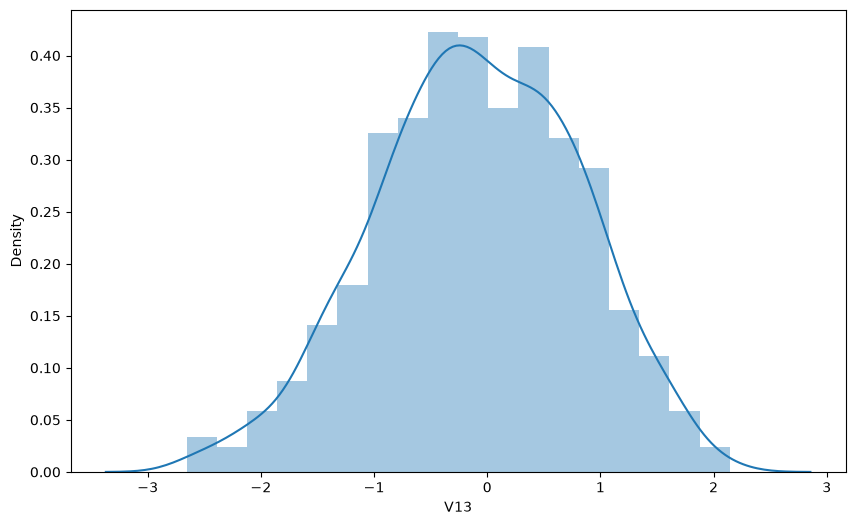

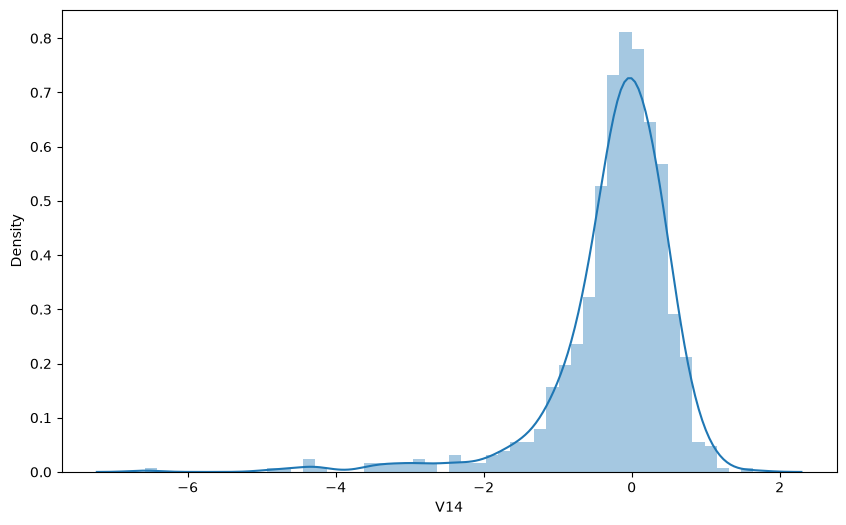

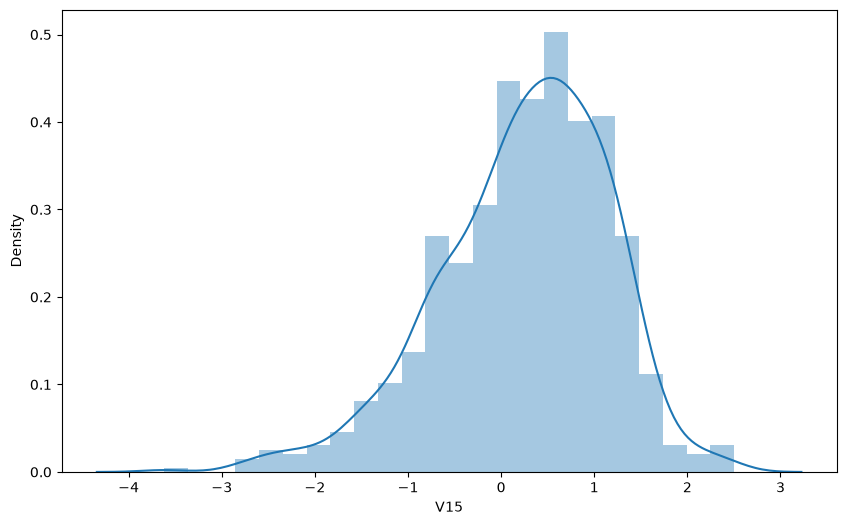

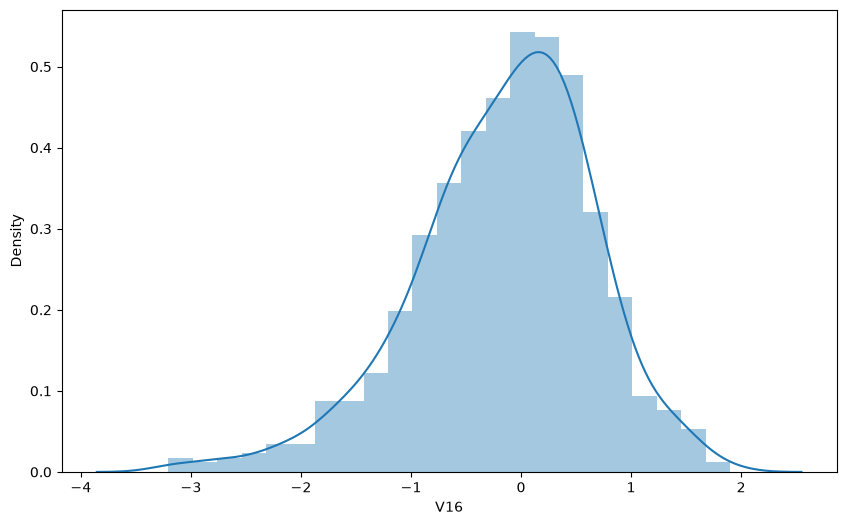

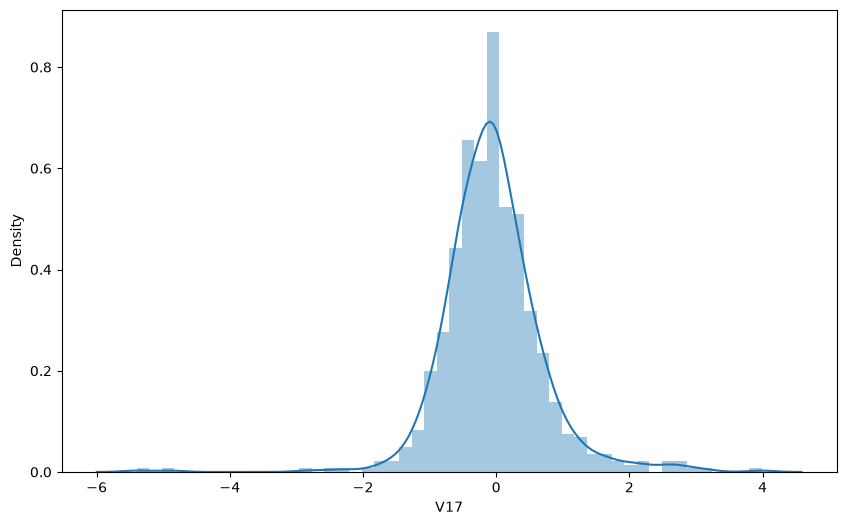

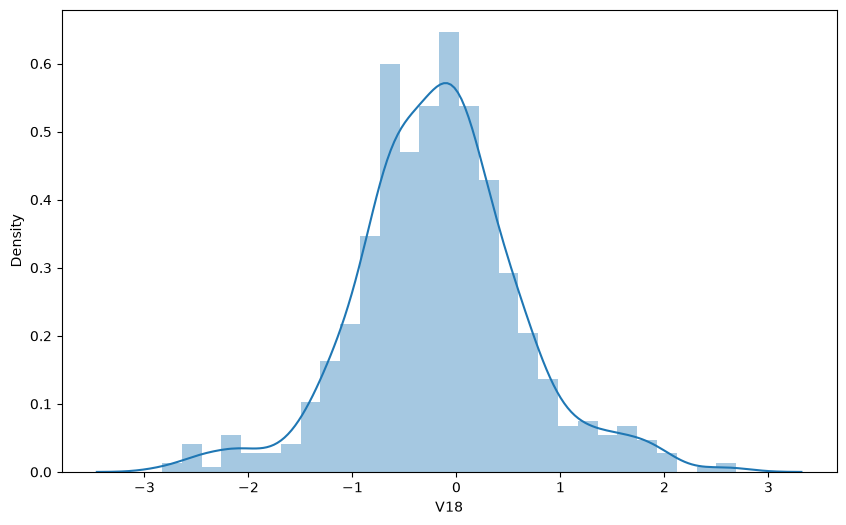

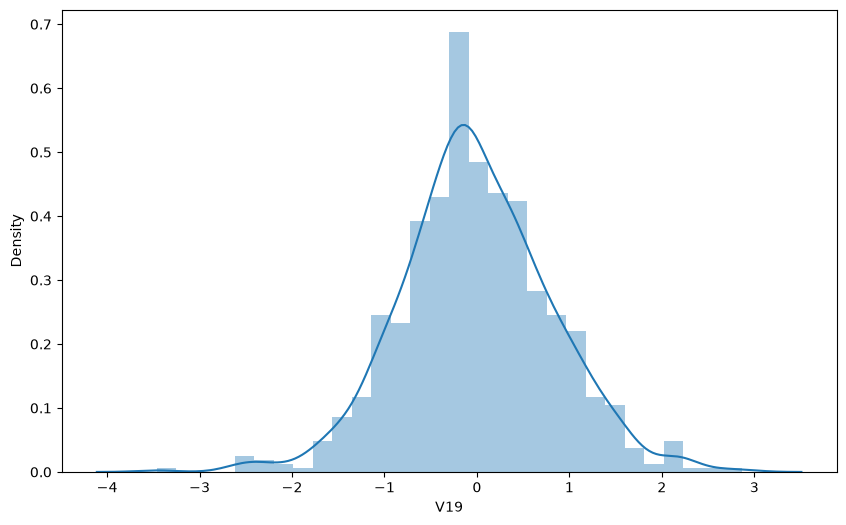

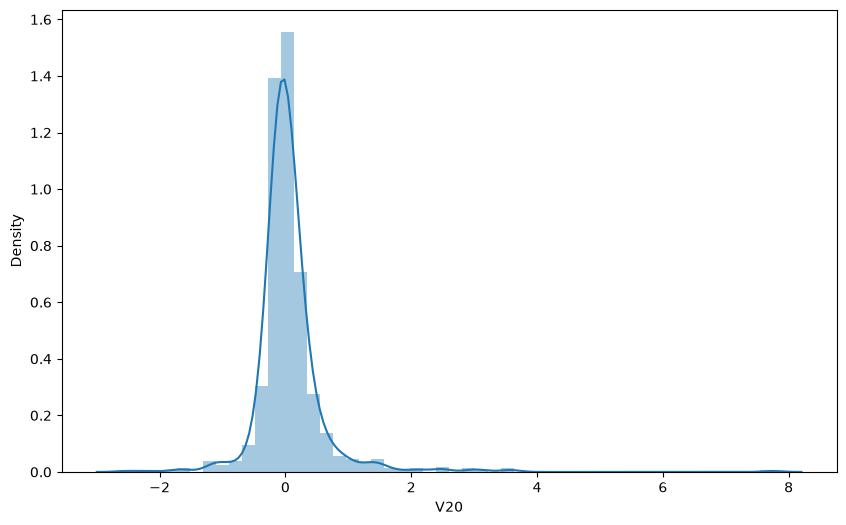

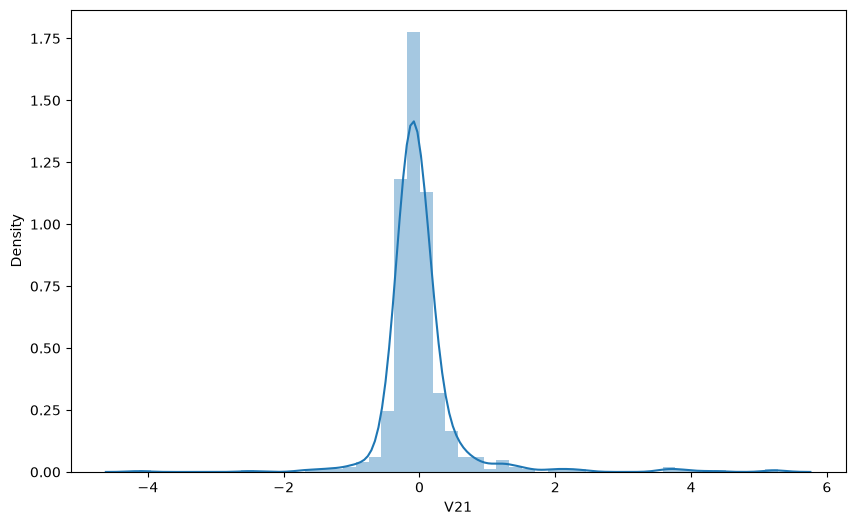

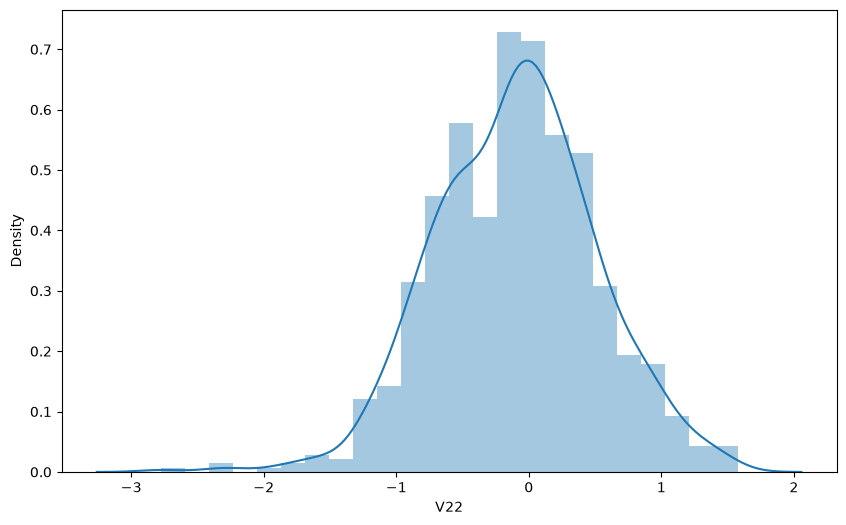

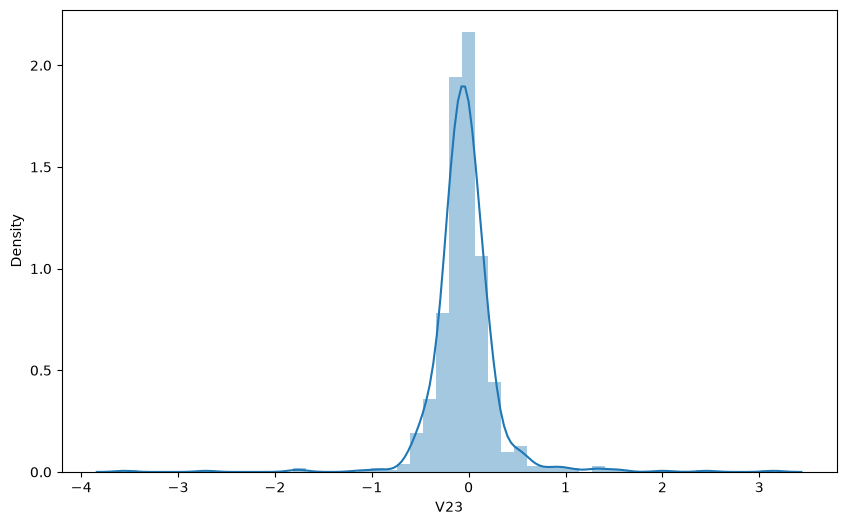

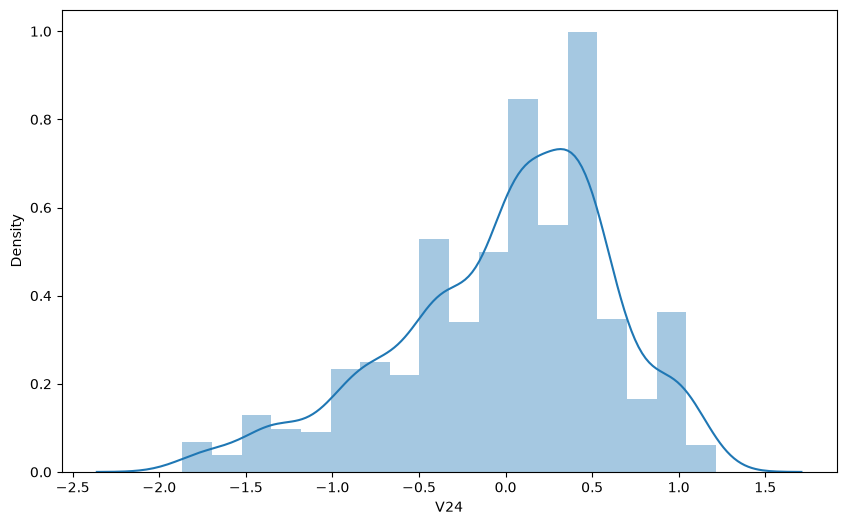

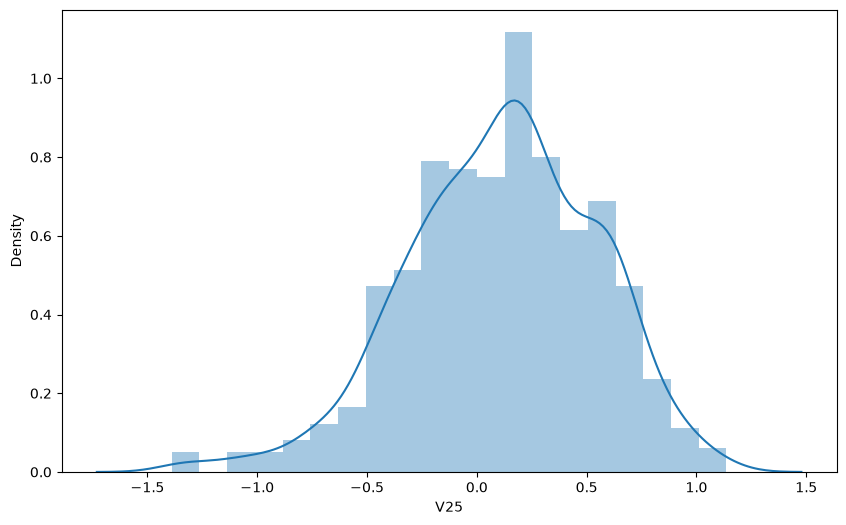

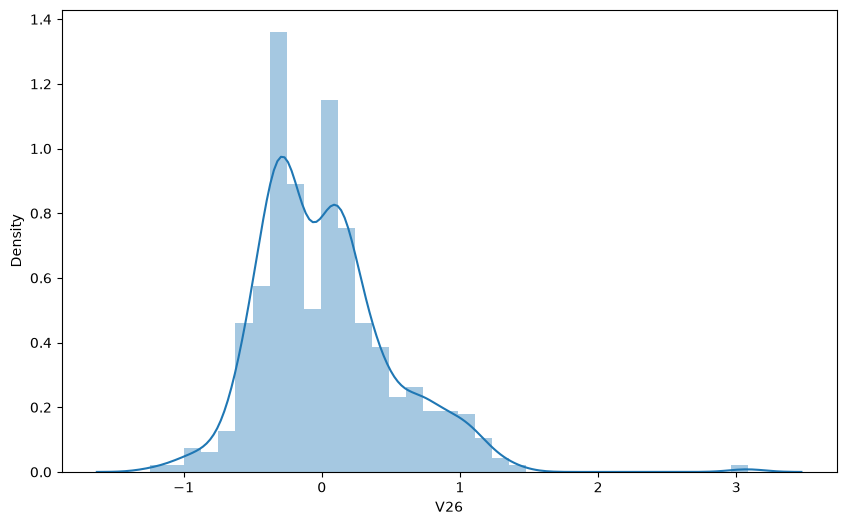

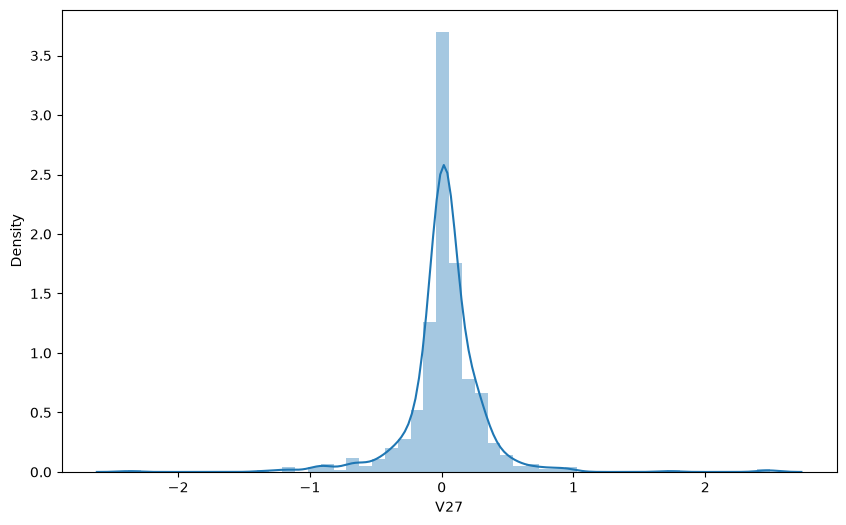

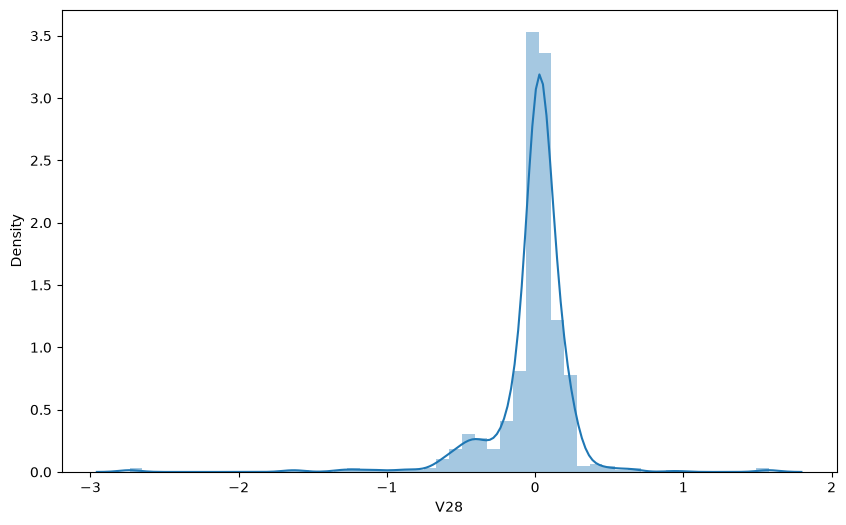

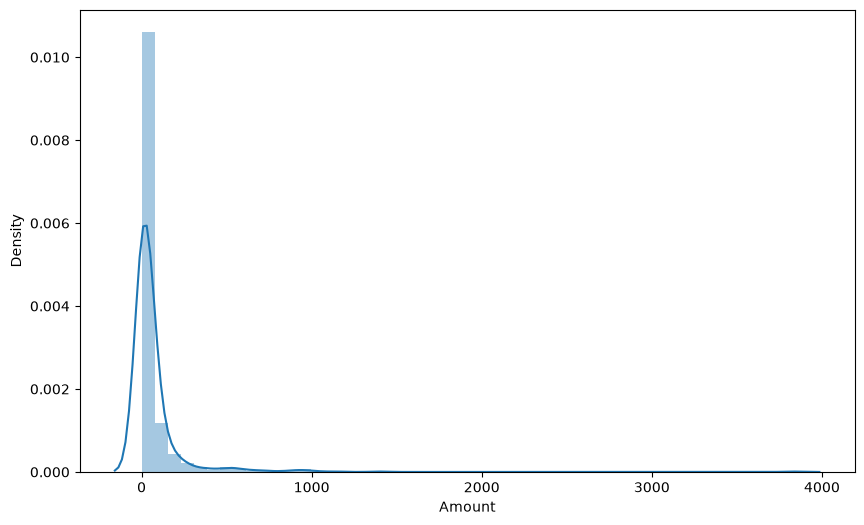

In [26]:
#plot each feature's distribution

for col in df.columns:
    plt.figure(figsize=(10, 6))
    sns.distplot(df[col])
    plt.xlabel(col)
    plt.show()

---
### **2. Clustering**


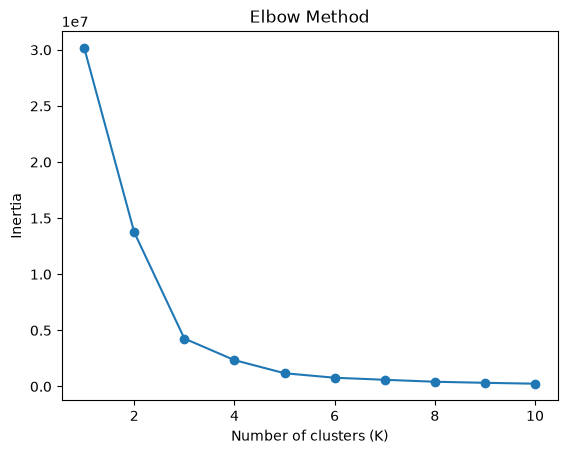

In [30]:
K_range = range(1, 11)
inertia = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df)
    inertia.append(kmeans.inertia_)

plt.figure()
plt.plot(K_range, inertia, marker='o')
plt.xlabel('Number of clusters (K)')
#plt.axvline(x=3, color='red', linestyle='--')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

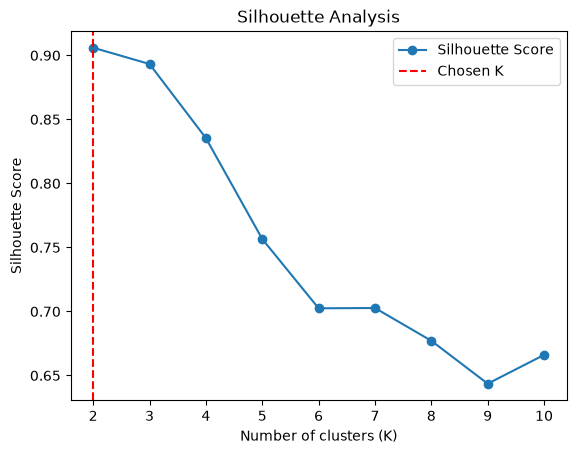

In [35]:
K_range = range(2, 11)
sil_scores = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(df)
    sil_scores.append(silhouette_score(df, labels))

plt.figure()
plt.plot(K_range, sil_scores, marker='o')
plt.xlabel('Number of clusters (K)')
plt.ylabel('Silhouette Score')
plt.axvline(x=2, color='red', linestyle='--') #chosen K is K=2
plt.legend(['Silhouette Score', 'Chosen K'])
plt.title('Silhouette Analysis')
plt.show()

In [37]:
chosen_k = 2

kmeans = KMeans(n_clusters=chosen_k, random_state=42, n_init=10)
labels_kmeans = kmeans.fit_predict(df)
df['KMeans_Cluster'] = labels_kmeans

# Evaluation metrics
sil_avg = silhouette_score(df, labels_kmeans)
db_index = davies_bouldin_score(df, labels_kmeans)
ch_index = calinski_harabasz_score(df, labels_kmeans)

print(f"Silhouette Score: {sil_avg:.4f}")
print(f"Davies-Bouldin Index: {db_index:.4f}")
print(f"Calinski-Harabasz Index: {ch_index:.4f}")

Silhouette Score: 0.9060
Davies-Bouldin Index: 0.4751
Calinski-Harabasz Index: 922.9297


---
### **3. Cluster Profiles**


---
### **4. Multiple Model Training for Classification**


---
### **5. Performance Metrics**


---
### **6. Conclusion**
